# Deepfake Detection using Transfer Learning
## ITS 530 — Deep Learning | Term Project | Spring 2026
### EfficientNet-B4 Fine-Tuned on Real vs Fake Face Images

## 0. Download Dataset

Run this section once to download and save the dataset to Google Drive. Skip if already done.

In [2]:
!pip install kaggle --quiet
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d /content/drive/MyDrive/deepfake_data

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [03:57<00:00, 16.9MB/s]

checkdir:  cannot create extraction directory: /content/drive/MyDrive/deepfake_data
           No such file or directory


In [3]:
# Step 2 — Download the dataset
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
print('Download complete.')

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
140k-real-and-fake-faces.zip: Skipping, found more recently modified local copy (use --force to force download)
Download complete.


In [4]:
# Step 3 — Mount Drive and unzip directly to Drive (so it persists)
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/deepfake_data', exist_ok=True)

!unzip -q 140k-real-and-fake-faces.zip -d /content/drive/MyDrive/deepfake_data
print('Unzip complete. Files saved to Drive.')
print(os.listdir('/content/drive/MyDrive/deepfake_data'))

Mounted at /content/drive
Unzip complete. Files saved to Drive.
['real_vs_fake', 'test.csv', 'train.csv', 'valid.csv']


## 1. Install Dependencies

In [5]:
!pip install timm grad-cam scikit-learn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 208.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Imports

In [6]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 3. Mount Drive and Set Paths

In [7]:
from google.colab import drive
try:
    drive.mount('/content/drive')
except ValueError:
    print('Drive already mounted.')

DATA_ROOT   = '/content/drive/MyDrive/deepfake_data/real_vs_fake/real-vs-fake'
CKPT_PATH   = '/content/drive/MyDrive/deepfake_best.pth'
RESULTS_DIR = '/content/drive/MyDrive/deepfake_results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Paths set.')
print('Data folder contents:', os.listdir('/content/drive/MyDrive/deepfake_data'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths set.
Data folder contents: ['real_vs_fake', 'test.csv', 'train.csv', 'valid.csv']


## 4. Transforms and DataLoaders

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

BATCH_SIZE = 32

train_ds = ImageFolder(root=os.path.join(DATA_ROOT, 'train'), transform=train_tf)
val_ds   = ImageFolder(root=os.path.join(DATA_ROOT, 'valid'), transform=val_tf)
test_ds  = ImageFolder(root=os.path.join(DATA_ROOT, 'valid'), transform=val_tf)

print('Class mapping:', train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Class mapping: {'fake': 0, 'real': 1}
Train batches: 3125 | Val: 625 | Test: 625


## 5. Model — EfficientNet-B4 with Layer Freezing

In [9]:
def build_efficientnet_b4(freeze_early=True):
    model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features  # 1792
    model.classifier[1] = nn.Linear(in_features, 1)
    if freeze_early:
        for i, block in enumerate(model.features):
            if i < 4:
                for param in block.parameters():
                    param.requires_grad = False
    return model

model = build_efficientnet_b4(freeze_early=True).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} params')

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 399MB/s]


Trainable: 17,281,047 / 17,550,409 params


## 6. Optimizer, Loss, and Scheduler

In [10]:
backbone_params = [p for name, p in model.named_parameters()
                   if p.requires_grad and 'classifier' not in name]
head_params     = list(model.classifier.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params,     'lr': 1e-3}
], weight_decay=1e-2)

criterion  = nn.BCEWithLogitsLoss()
NUM_EPOCHS = 20
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler     = torch.cuda.amp.GradScaler()

print('Optimizer, scheduler, and AMP scaler configured.')

Optimizer, scheduler, and AMP scaler configured.


## 7. Training and Evaluation Functions

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs).squeeze(1)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    preds_bin = (np.array(all_preds) >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_bin)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, acc, auc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)
            with torch.cuda.amp.autocast():
                outputs = model(imgs).squeeze(1)
                loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    preds_bin = (np.array(all_preds) >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_bin)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, acc, auc, np.array(all_preds), np.array(all_labels)

print('Training functions defined.')

Training functions defined.


## 8. Training Loop

In [12]:
history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_val_auc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_auc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    va_loss, va_acc, va_auc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(va_auc)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  AUC: {tr_auc:.4f} | '
          f'Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f}  AUC: {va_auc:.4f}')

    if va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  --> Best Val AUC: {best_val_auc:.4f} (checkpoint saved)')

print(f'\nTraining complete. Best Val AUC: {best_val_auc:.4f}')

Epoch 01/20 | Train Loss: 0.4014  Acc: 0.8181  AUC: 0.9001 | Val Loss: 0.3075  Acc: 0.8706  AUC: 0.9433
  --> Best Val AUC: 0.9433 (checkpoint saved)
Epoch 02/20 | Train Loss: 0.2517  Acc: 0.8949  AUC: 0.9614 | Val Loss: 0.2196  Acc: 0.9110  AUC: 0.9717
  --> Best Val AUC: 0.9717 (checkpoint saved)
Epoch 03/20 | Train Loss: 0.1873  Acc: 0.9249  AUC: 0.9785 | Val Loss: 0.1699  Acc: 0.9317  AUC: 0.9843
  --> Best Val AUC: 0.9843 (checkpoint saved)
Epoch 04/20 | Train Loss: 0.1479  Acc: 0.9419  AUC: 0.9865 | Val Loss: 0.1447  Acc: 0.9425  AUC: 0.9893
  --> Best Val AUC: 0.9893 (checkpoint saved)
Epoch 05/20 | Train Loss: 0.1233  Acc: 0.9520  AUC: 0.9905 | Val Loss: 0.1175  Acc: 0.9543  AUC: 0.9923
  --> Best Val AUC: 0.9923 (checkpoint saved)
Epoch 06/20 | Train Loss: 0.1052  Acc: 0.9595  AUC: 0.9931 | Val Loss: 0.1020  Acc: 0.9611  AUC: 0.9944
  --> Best Val AUC: 0.9944 (checkpoint saved)
Epoch 07/20 | Train Loss: 0.0930  Acc: 0.9639  AUC: 0.9946 | Val Loss: 0.0982  Acc: 0.9634  AUC: 0.9

## 9. Training Curves

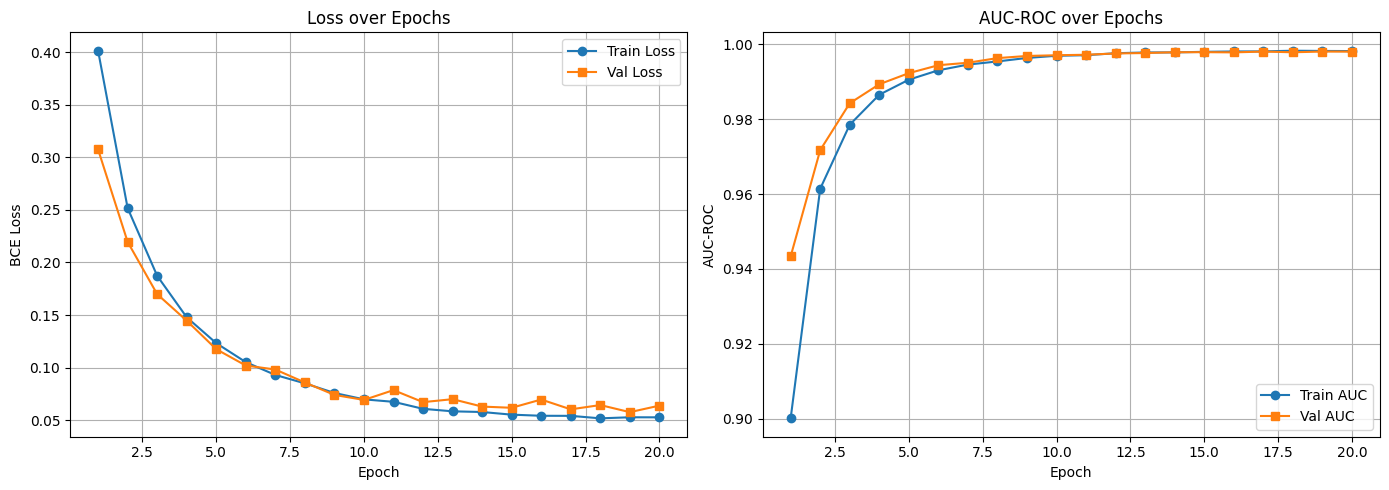

In [13]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history['train_auc'], label='Train AUC', marker='o')
axes[1].plot(epochs, history['val_auc'],   label='Val AUC',   marker='s')
axes[1].set_title('AUC-ROC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 10. Load Best Checkpoint and Evaluate on Test Set

In [14]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

_, te_acc, te_auc, te_probs, te_labels = evaluate(model, test_loader, criterion, device)
te_preds = (te_probs >= 0.5).astype(int)

te_f1   = f1_score(te_labels, te_preds)
te_prec = precision_score(te_labels, te_preds)
te_rec  = recall_score(te_labels, te_preds)

print('===== Test Set Results =====')
print(f'Accuracy:  {te_acc:.4f}')
print(f'AUC-ROC:   {te_auc:.4f}')
print(f'F1 Score:  {te_f1:.4f}')
print(f'Precision: {te_prec:.4f}')
print(f'Recall:    {te_rec:.4f}')

===== Test Set Results =====
Accuracy:  0.9785
AUC-ROC:   0.9981
F1 Score:  0.9783
Precision: 0.9868
Recall:    0.9699


## 11. Confusion Matrix

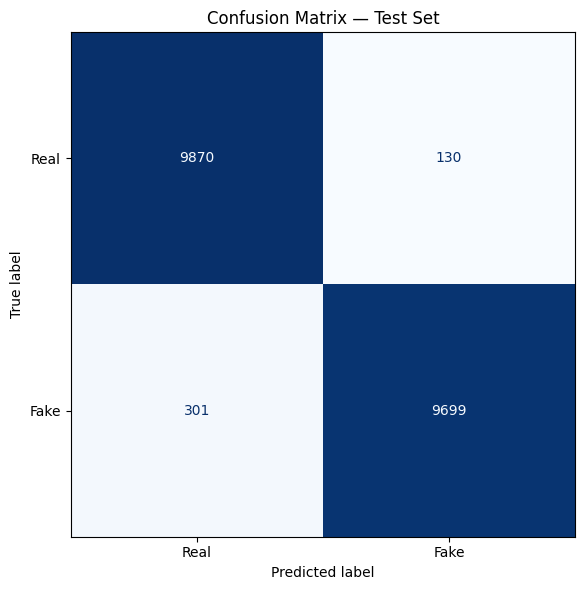

In [15]:
cm   = confusion_matrix(te_labels, te_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 12. GradCAM Visualization

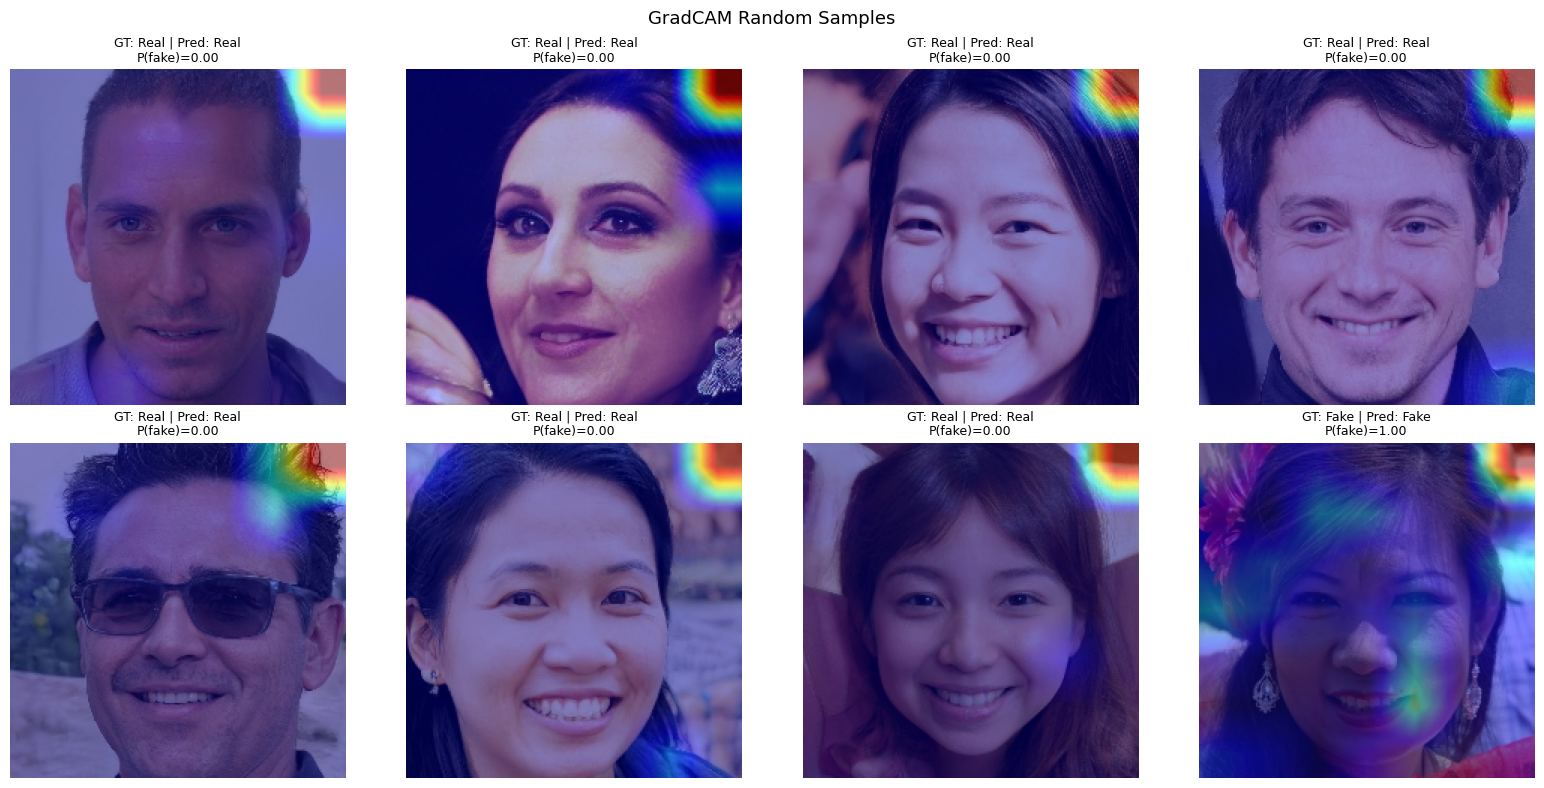

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)


def show_gradcam(dataset, indices, n_cols=4, title='GradCAM'):
    n_rows = (len(indices) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)

    for ax_i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        input_tensor  = img_tensor.unsqueeze(0).to(device)
        grayscale_cam = cam(input_tensor=input_tensor)[0]

        img_np  = img_tensor.permute(1, 2, 0).numpy()
        img_np  = np.clip(std * img_np + mean, 0, 1)
        cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        with torch.no_grad():
            prob = torch.sigmoid(model(input_tensor)).item()

        gt   = 'Fake' if int(label) == 1 else 'Real'
        pred = 'Fake' if prob >= 0.5 else 'Real'
        axes[ax_i].imshow(cam_img)
        axes[ax_i].set_title(f'GT: {gt} | Pred: {pred}\nP(fake)={prob:.2f}', fontsize=9)
        axes[ax_i].axis('off')

    for ax_i in range(len(indices), len(axes)):
        axes[ax_i].axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'{title.replace(" ","_")}.png'), dpi=150, bbox_inches='tight')
    plt.show()


sample_indices = random.sample(range(len(test_ds)), min(8, len(test_ds)))
show_gradcam(test_ds, sample_indices, n_cols=4, title='GradCAM Random Samples')

## 13. Failure Case Analysis — Top-20 Most Confidently Wrong Predictions

Total wrong predictions: 431


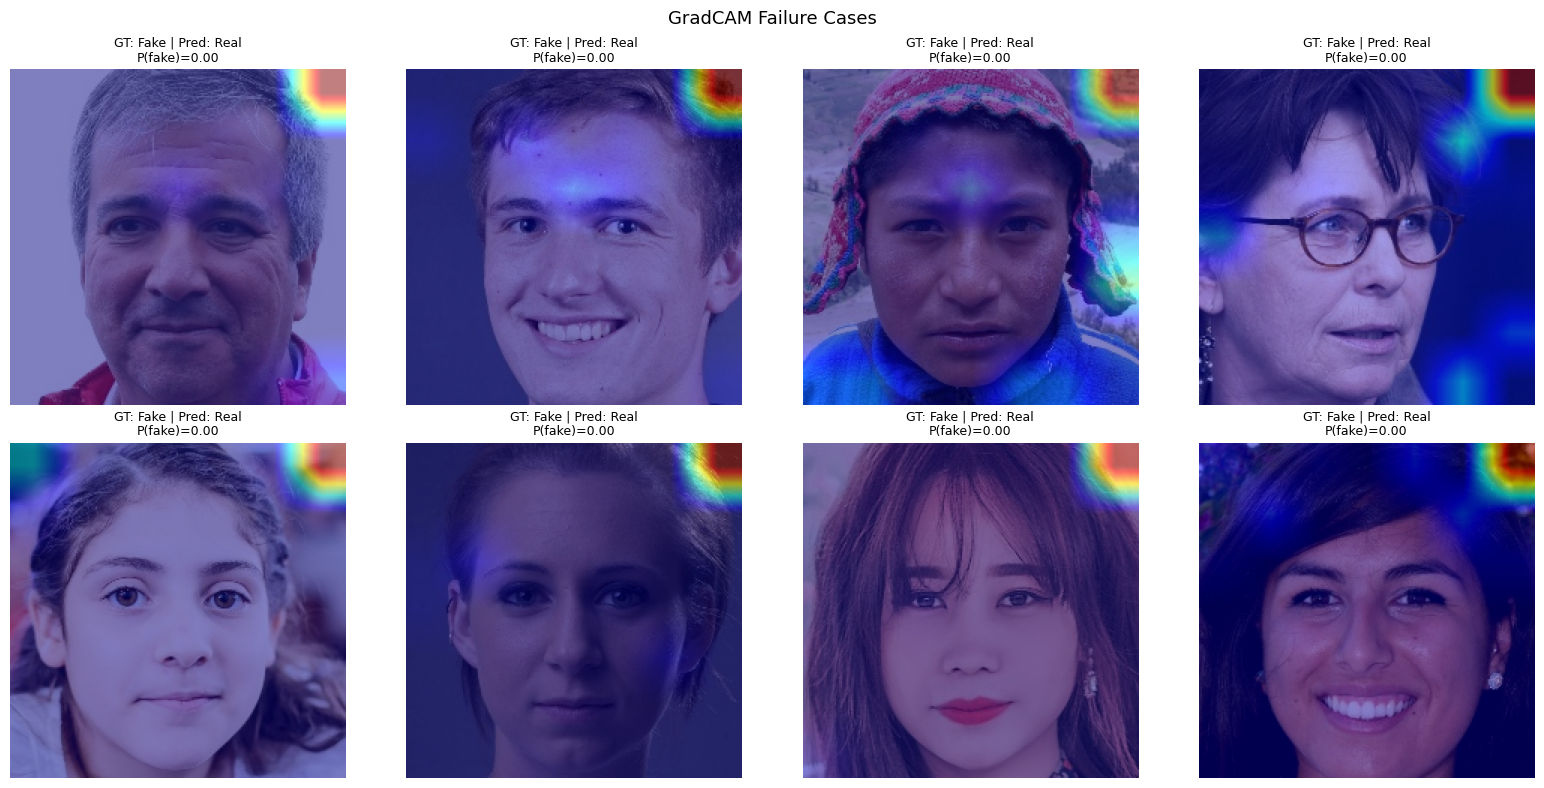

In [17]:
wrong_mask = (te_preds != te_labels.astype(int))
wrong_idx  = np.where(wrong_mask)[0]
wrong_conf = np.abs(te_probs[wrong_idx] - 0.5)
top20_idx  = wrong_idx[np.argsort(wrong_conf)[::-1][:20]]

print(f'Total wrong predictions: {len(wrong_idx)}')
show_gradcam(test_ds, top20_idx[:8].tolist(), n_cols=4, title='GradCAM Failure Cases')

## 14. Ablation Study — Frozen vs Fine-Tuned Backbone

In [18]:
def build_frozen_efficientnet():
    m = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
    for param in m.parameters():
        param.requires_grad = False
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    return m


def quick_train(model_fn, epochs=5):
    m   = model_fn().to(device)
    opt = optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-3)
    scl = torch.cuda.amp.GradScaler()
    crt = nn.BCEWithLogitsLoss()
    best = 0.0
    for _ in range(epochs):
        train_one_epoch(m, train_loader, opt, crt, scl, device)
        _, _, auc, _, _ = evaluate(m, val_loader, crt, device)
        if auc > best:
            best = auc
    return best


print('Running frozen backbone ablation (5 epochs)...')
frozen_auc = quick_train(build_frozen_efficientnet, epochs=5)

print('\nAblation Summary:')
print(f'  Frozen backbone (5 epochs):   Val AUC = {frozen_auc:.4f}')
print(f'  Fine-tuned {NUM_EPOCHS} epochs (best): Val AUC = {best_val_auc:.4f}')

Running frozen backbone ablation (5 epochs)...

Ablation Summary:
  Frozen backbone (5 epochs):   Val AUC = 0.8737
  Fine-tuned 20 epochs (best): Val AUC = 0.9981


## 15. Upload and Predict a Single Image

Click "Choose Files" to upload a face image


Saving ai-face-generator-european-women.webp to ai-face-generator-european-women.webp

File:       ai-face-generator-european-women.webp
Prediction: FAKE
Confidence: 100.00%
P(fake):    1.0000


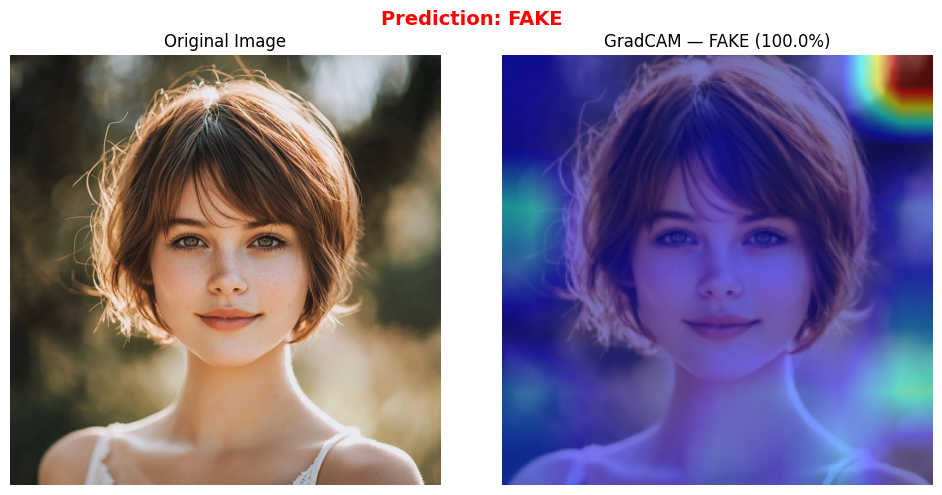

In [22]:
from google.colab import files
import io

print('Click "Choose Files" to upload a face image')
uploaded = files.upload()

if uploaded:
    fname     = list(uploaded.keys())[0]
    img_bytes = uploaded[fname]
    img_pil   = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    input_tensor = val_tf(img_pil).unsqueeze(0).to(device)

    model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
    model.eval()

    with torch.no_grad():
        prob = torch.sigmoid(model(input_tensor)).item()

    pred_label = 'FAKE' if prob >= 0.5 else 'REAL'
    confidence = prob if prob >= 0.5 else 1 - prob

    print(f'\nFile:       {fname}')
    print(f'Prediction: {pred_label}')
    print(f'Confidence: {confidence:.2%}')
    print(f'P(fake):    {prob:.4f}')

    cam_obj       = GradCAM(model=model, target_layers=[model.features[-1]])
    grayscale_cam = cam_obj(input_tensor=input_tensor)[0]

    mean    = np.array(IMAGENET_MEAN)
    std     = np.array(IMAGENET_STD)
    img_np  = val_tf(img_pil).permute(1, 2, 0).numpy()
    img_np  = np.clip(std * img_np + mean, 0, 1)
    cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_pil)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(cam_img)
    axes[1].set_title(f'GradCAM — {pred_label} ({confidence:.1%})', fontsize=12)
    axes[1].axis('off')
    plt.suptitle(f'Prediction: {pred_label}', fontsize=14, fontweight='bold',
                 color='red' if pred_label == 'FAKE' else 'green')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'prediction_{fname}'), dpi=150, bbox_inches='tight')
    plt.show()

## 16. Final Results Summary

In [23]:
print('=' * 52)
print('   DEEPFAKE DETECTION — FINAL RESULTS SUMMARY')
print('   ITS 530 | Spring 2026')
print('=' * 52)
print(f'  Backbone:     EfficientNet-B4 (ImageNet pretrained)')
print(f'  Dataset:      140k Real and Fake Faces')
print(f'  Epochs:       {NUM_EPOCHS}')
print(f'  Best Val AUC: {best_val_auc:.4f}')
print()
print('  Test Set Metrics:')
print(f'    Accuracy:   {te_acc:.4f}')
print(f'    AUC-ROC:    {te_auc:.4f}')
print(f'    F1 Score:   {te_f1:.4f}')
print(f'    Precision:  {te_prec:.4f}')
print(f'    Recall:     {te_rec:.4f}')
print('=' * 52)

   DEEPFAKE DETECTION — FINAL RESULTS SUMMARY
   ITS 530 | Spring 2026
  Backbone:     EfficientNet-B4 (ImageNet pretrained)
  Dataset:      140k Real and Fake Faces
  Epochs:       20
  Best Val AUC: 0.9981

  Test Set Metrics:
    Accuracy:   0.9785
    AUC-ROC:    0.9981
    F1 Score:   0.9783
    Precision:  0.9868
    Recall:     0.9699
